In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
original_data = pd.read_csv("responses_22.csv")

In [3]:
# Function to create dictionary for renaming columns
def edit_cols(cols):
    nudge_num = 1
    risk_num = 1
    col_dict = {}
    for i, OLD_col in enumerate(cols):
        col = OLD_col.lower().strip()
        if col[0].isnumeric():
            first_word = col.split(" ")[1]
            if first_word == "select":
                NEW_col = "risk_" + str(risk_num)
                risk_num += 1
            elif first_word == "this":
                NEW_col = "nudge_" + str(nudge_num)
                nudge_num += 1
        elif "age" in col:
            NEW_col = "age"
        elif "parents" in col:
            NEW_col = "parent_edu"
        elif "income" in col:
            NEW_col = "income"
        elif col == "what do you think this survey was about?":
            NEW_col = "participant_bias"
        elif "questions" in col:
            NEW_col = "comments"
        else:
            NEW_col = col
        
        col_dict[OLD_col] = NEW_col
    
    return col_dict

In [4]:
# Create dictionary for column name mapping; rename columns
col_dict = edit_cols(original_data.columns)
data = original_data.rename(columns=col_dict)

# Basic data cleaning
data = data.map(lambda x: x.strip()[-1] if "option" in str(x).lower() else x)

gender_dict = {"Man": "M", "Woman": "W", "Non-binary": "NB"}
data['gender'] = data['gender'].map(gender_dict)

data.replace({"Grad Student": "Graduate", "I'm not a student": "Non-Student", "Prefer not to specify": "PNTS"}, inplace=True)

for col in data.columns:
    if "nudge" in col:
        data[col] = data[col].map(lambda x: x if x == "B" else "none")

data['participant'] = ["P" + str(val) for val in np.arange(len(data)) + 1]

In [5]:
data.head()

,timestamp,gender,year,age,parent_edu,income,risk_1,risk_2,nudge_1,nudge_2,...,nudge_6,nudge_7,risk_9,nudge_8,risk_10,nudge_9,nudge_10,participant_bias,comments,participant
0,2/28/2026 20:38:36,M,Senior,22-25,Masters or professional degree,PNTS,A,A,none,none,...,none,none,A,none,A,none,none,Your family background and its implication on...,Cool stuff,P1
1,2/28/2026 20:44:12,M,Junior,18-21,Masters or professional degree,"$250,000+",A,A,none,none,...,B,B,A,B,B,B,B,A supposed correlation between financial choic...,I have OCD,P2
2,2/28/2026 20:44:32,M,Senior,22-25,Undergraduate degree,"$100,000-200,000",B,B,B,B,...,B,none,B,B,B,none,B,s,NaN,P3
3,3/1/2026 12:56:50,W,Junior,18-21,Masters or professional degree,"$250,000+",B,B,B,B,...,B,none,A,none,B,none,B,Risk tolerance,Too many qs; wasn’t thinking as critically at ...,P4
4,3/1/2026 13:02:04,W,Freshman,18-21,Undergraduate degree,"$100,000-200,000",B,B,B,B,...,B,none,B,B,A,B,none,.,NaN,P5


In [6]:
# Create DataFrame to store question information
questions_df = pd.DataFrame(index = [col for col in data.columns if "risk" in col or "nudge" in col])

# Extract and store the opetions for each question
for key, val in col_dict.items():
    if "risk" in val or "nudge" in val:
        for i in key.strip().split("\n"):
            if "option a" in i.lower():
                questions_df.loc[val, 'Option_A'] = i.split(":")[-1].strip()
            elif "option b" in i.lower():
                questions_df.loc[val, 'Option_B'] = i.split(":")[-1].strip()

# Indicate whic option is riskier (manually determined) 
risky_choice = np.array(["A", "A", "A", "A", "B", "B", "B", "B", "A", "B", "B", "B", "A", "A", "B", "A", "B", "B", "B", "B"])
questions_df['risky_choice'] = risky_choice

# Indicate direction of nudge (if applicable)
for question in questions_df.index:
    if "nudge" in question:
        if questions_df.loc[question, 'risky_choice'] == "A":
            questions_df.loc[question, 'nudge_direction'] = "to_risky"
        else:
            questions_df.loc[question, 'nudge_direction'] = "to_safe"
    else:   
        questions_df.loc[question, 'nudge_direction'] = "none"

questions_df.reset_index(inplace=True)

In [7]:
questions_df

,index,Option_A,Option_B,risky_choice,nudge_direction
0,risk_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,none
1,risk_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,none
2,nudge_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,to_risky
3,nudge_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,to_risky
4,risk_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,none
5,nudge_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,to_safe
6,risk_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,none
7,risk_5,100% chance of $220,"50% chance of $400, 50% chance of $40",B,none
8,risk_6,"25% chance of $800, 75% chance of $100",100% chance of $310,A,none
9,nudge_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,to_safe


In [8]:
def format_outcomes(col):
    choices = []
    for choice in questions_df[col]:
        outcome_list = choice.split(",")
        outcomes = []
        for outcome in outcome_list:
            outcome = re.sub(r'[^\w\s%$]', "", outcome)
            outcome = outcome.strip().split(" ")
            formatted_outcome = []
            for item in outcome:
                if item.endswith("%"):
                    p = item.strip("%")
                    p = float(p) / 100
                    formatted_outcome.append(p)
                elif item.startswith("$"):
                    v = item.strip("$")
                    v = float(v)
                    formatted_outcome.append(v)

            if len(formatted_outcome) != 2:
                formatted_outcome.append(0)
            outcomes.append(formatted_outcome)
        choices.append(outcomes)
    return choices


In [9]:
questions_df["outcomes_A"] = format_outcomes("Option_A")
questions_df["outcomes_B"] = format_outcomes("Option_B")

In [10]:
questions_df

,index,Option_A,Option_B,risky_choice,nudge_direction,outcomes_A,outcomes_B
0,risk_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,none,"[[0.4, 300.0], [0.6, 0]]","[[1.0, 110.0]]"
1,risk_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,none,"[[0.4, 200.0], [0.6, 0]]","[[1.0, 80.0]]"
2,nudge_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,to_risky,"[[0.4, 300.0], [0.6, 0]]","[[1.0, 110.0]]"
3,nudge_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,to_risky,"[[0.4, 200.0], [0.6, 0]]","[[1.0, 80.0]]"
4,risk_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,none,"[[1.0, 50.0]]","[[0.5, 100.0], [0.5, 0]]"
5,nudge_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,to_safe,"[[1.0, 50.0]]","[[0.5, 100.0], [0.5, 0]]"
6,risk_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,none,"[[1.0, 20.0]]","[[0.5, 45.0], [0.5, 0]]"
7,risk_5,100% chance of $220,"50% chance of $400, 50% chance of $40",B,none,"[[1.0, 220.0]]","[[0.5, 400.0], [0.5, 40.0]]"
8,risk_6,"25% chance of $800, 75% chance of $100",100% chance of $310,A,none,"[[0.25, 800.0], [0.75, 100.0]]","[[1.0, 310.0]]"
9,nudge_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,to_safe,"[[1.0, 20.0]]","[[0.5, 45.0], [0.5, 0]]"


In [11]:
shannon_entropy = lambda x: x * np.log2(x)

def calculate_entropy(col):
    entropy_col = []
    for outcomes in questions_df[col]:
        p_list = []
        for outcome in outcomes:
            p_list.append(outcome[0])
        shannon = map(shannon_entropy, p_list)
        entropy_sum = -1 * sum(shannon)
    entropy_col.append(entropy_sum)
    return entropy_col

# questions_df["entropy_A"] = calculate_entropy("outcomes_A")
# questions_df["entropy_B"] = calculate_entropy("outcomes_B")

0       risk_1
1       risk_2
2      nudge_1
3      nudge_2
4       risk_3
5      nudge_3
6       risk_4
7       risk_5
8       risk_6
9      nudge_4
10     nudge_5
11      risk_7
12      risk_8
13     nudge_6
14     nudge_7
15      risk_9
16     nudge_8
17     risk_10
18     nudge_9
19    nudge_10
Name: index, dtype: str

In [12]:
# Create DataFrame to store participant response classes to risk and nudge questions
risk_df = data[questions_df['index'].to_list() + ["participant"]]

# Classify participant responses as "R" (risky) or "S" (safe); add nudge acceptance column for nudge questions (1 for acceptance, 0 for rejection)
for col in risk_df.columns:
    if col != "participant":
        risky_choice = questions_df.loc[col, 'risky_choice']
        if "risk" in col:
            risk_df[col] = risk_df[col].map(lambda x: "R" if x == risky_choice else "S")
        elif "nudge" in col:
            risk_df[f"{col}_accept"] = risk_df[col].map(lambda x: 1 if x == 'none' else 0)
            risk_df[col] = risk_df[col].map(lambda x: x if x == "B" else "A").map(lambda x: "R" if x == risky_choice else "S")

risk_df["pure_risk_preference"] = risk_df[[col for col in risk_df.columns if "risk" in col]].apply(lambda x: sum(x == "R")/10, axis=1)
risk_df["nudge_susceptibility"] = risk_df[[col for col in risk_df.columns if "nudge" in col and "accept" in col]].apply(lambda x: sum(x == 1)/10, axis=1)


# risk_df["nudge_susceptibility_to_risk"] = risk_df[[col for col in risk_df.columns if ]]

KeyError: 'risk_1'

In [ ]:
to_risky = questions_df[questions_df['nudge_direction'] == "to_risky"].index.to_list()
to_risky

['nudge_1', 'nudge_2', 'nudge_6', 'nudge_8']

In [ ]:
risk_df

,risk_1,risk_2,nudge_1,nudge_2,risk_3,nudge_3,risk_4,risk_5,risk_6,nudge_4,...,nudge_3_accept,nudge_4_accept,nudge_5_accept,nudge_6_accept,nudge_7_accept,nudge_8_accept,nudge_9_accept,nudge_10_accept,pure_risk_preference,nudge_susceptibility
0,R,R,R,R,S,S,R,S,S,S,...,1,1,1,1,1,1,1,1,0.5,1.0
1,R,R,R,R,R,R,S,R,S,R,...,0,0,1,0,0,0,0,0,0.7,0.3
2,S,S,S,S,S,S,S,S,S,S,...,1,1,1,0,1,0,1,0,0.3,0.5
3,S,S,S,S,S,S,R,S,S,R,...,1,0,1,0,1,1,1,0,0.4,0.5
4,S,S,S,S,R,S,R,S,S,S,...,1,1,1,0,1,0,0,1,0.4,0.5
5,S,S,S,S,S,S,R,S,S,R,...,1,0,1,0,1,1,1,1,0.1,0.6
6,R,S,R,S,S,S,R,S,S,R,...,1,0,1,0,0,0,0,0,0.6,0.3
7,S,S,S,S,S,S,S,S,S,S,...,1,1,1,0,1,1,0,1,0.1,0.6
8,S,S,S,S,S,S,S,S,S,R,...,1,0,1,1,0,0,0,0,0.2,0.3
9,R,S,R,S,S,S,R,S,S,R,...,1,0,1,0,1,0,0,1,0.4,0.5


<Axes: xlabel='pure_risk_preference', ylabel='Count'>

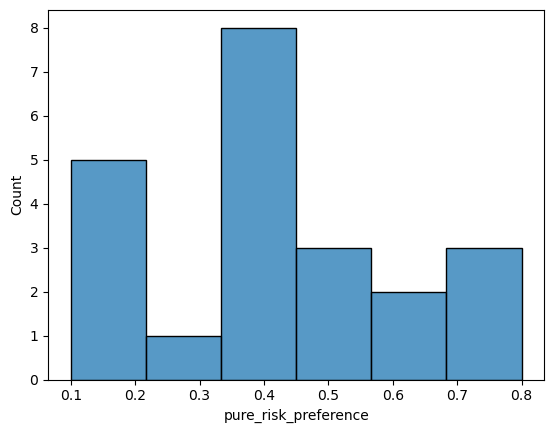

In [ ]:
sns.histplot(data=risk_df["pure_risk_preference"])

<Axes: xlabel='nudge_susceptibility', ylabel='Count'>

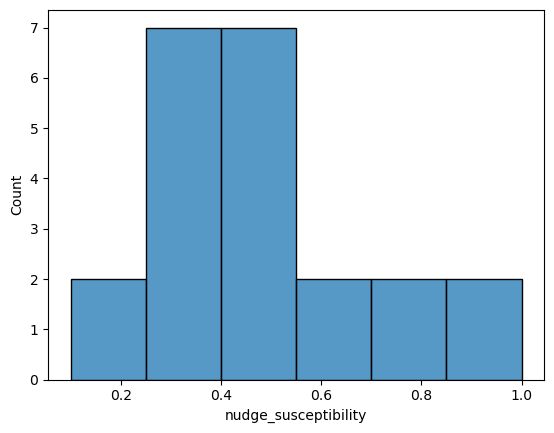

In [ ]:
sns.histplot(data=risk_df["nudge_susceptibility"])